# 📘 AppleStore_EDA.ipynb



## 📌 Step 1: Import Required Libraries


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [73]:

# Optional settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")



### 📌 Step 2: Load Cleaned CSV


In [3]:
df = pd.read_csv(r"D:\sql_python_mastery\Python_Journey\01_Apple_Store_Analytics_Project\cleaned_apple_store_data.csv")




#### 📌 Step 3: Revenue Column (if not already saved)


In [74]:
if 'revenue' not in df.columns:
    df['revenue'] = df['quantity'] * df['price']



#### 📌 Step 4: Total Revenue by Category


In [5]:
total_revenue_by_category = (
    df.groupby('category_name')['revenue']
    .sum()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)
print("\n💰 Total Revenue by Product Category:")
print(total_revenue_by_category)



💰 Total Revenue by Product Category:
  category_name   revenue
1       Laptops  295214.0
2   Smartphones  181168.0
3       Tablets  157986.0
0   Accessories  122990.0



#### 📌 Step 5: Store with Highest Number of Sales


In [76]:
store_sales = df.groupby('store_name')['quantity'].sum().reset_index()
store_sales = store_sales.sort_values(by='quantity', ascending=False)
top_store = store_sales.iloc[0]
print("\n🏬 Highest Sales Store:")
print(f"{top_store['store_name']} → {top_store['quantity']} units sold")



🏬 Highest Sales Store:
Apple Store San Antonio → 14 units sold



#### 📌 Step 6: Average Sale Value per Store


In [77]:
avg_sales = df.groupby('store_name')['revenue'].mean().reset_index()
avg_sales = avg_sales.sort_values(by='revenue', ascending=False)
print("\n📊 Average Sale Value per Store:")
print(avg_sales.head())



📊 Average Sale Value per Store:
                  store_name  revenue
101  Apple Store Los Angeles  15326.5
1      Apple Store  Fairview   9497.5
45     Apple Store Cleveland   8395.0
113        Apple Store Miami   7794.0
57        Apple Store Durham   7794.0



#### 📌 Step 7: Top 5 Products by Quantity Sold


In [78]:
top_products = (
    df.groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n📦 Top 5 Best-Selling Products:")
print(top_products.head())



📦 Top 5 Best-Selling Products:
          product_name  quantity
117     iPhone 13 Mini        29
84         iPad Aurora        19
40         Mac Mini M2        15
133      iPhone 8 Plus        14
127  iPhone 16 Pro Max        13


### 📊 Sales Analysis

In [79]:
#1. What is the total revenue generated across all stores?
total_revenue = df['revenue'].sum()
print(f"\n💵 Total Revenue Generated: ${total_revenue:,.2f}")



💵 Total Revenue Generated: $760,858.00


In [81]:
#2. Which product generated the highest revenue?
highest_revenue_product = df.groupby('product_name')['revenue'].sum().idxmax()
highest_revenue = df.groupby('product_name')['revenue'].sum().max() 
print(f"\n💰 Product with Highest Revenue: {highest_revenue_product} (${highest_revenue:,.2f})")



💰 Product with Highest Revenue: Mac Pro (2019) ($65,989.00)


In [82]:
#3. What is the total revenue by product category?
total_revenue_by_category = df.groupby('category_name')['revenue'].sum().reset_index()
total_revenue_by_category = total_revenue_by_category.sort_values(by='revenue', ascending=False)
print("\n📊 Total Revenue by Product Category:")
print(total_revenue_by_category.head()) 



📊 Total Revenue by Product Category:
  category_name  revenue
1       Laptops   295214
2   Smartphones   181168
3       Tablets   161486
0   Accessories   122990


In [83]:
#4. Which store has the highest number of sales?
store_sales = df.groupby('store_name')['quantity'].sum().reset_index()
store_sales = store_sales.sort_values(by='quantity', ascending=False)
top_store = store_sales.iloc[0]
print("\n🏬 Highest Sales Store:")
print(f"{top_store['store_name']} → {top_store['quantity']} units sold")



🏬 Highest Sales Store:
Apple Store San Antonio → 14 units sold


In [84]:
# 5. Which city has the highest total revenue?
city_revenue = df.groupby('city')['revenue'].sum().reset_index()
city_revenue = city_revenue.sort_values(by='revenue', ascending=False)
print("\n🌆 City with Highest Total Revenue:")
print(f"{city_revenue.iloc[0]['city']} → ${city_revenue.iloc[0]['revenue']:,.2f}")



🌆 City with Highest Total Revenue:
Los Angeles → $30,653.00


In [85]:
# 6. What is the average sale value per store?
avg_sales = df.groupby('store_name')['revenue'].mean().reset_index()
avg_sales = avg_sales.sort_values(by='revenue', ascending=False)
print("\n📊 Average Sale Value per Store:")
print(avg_sales.head())



📊 Average Sale Value per Store:
                  store_name  revenue
101  Apple Store Los Angeles  15326.5
1      Apple Store  Fairview   9497.5
45     Apple Store Cleveland   8395.0
113        Apple Store Miami   7794.0
57        Apple Store Durham   7794.0


### 📦 Product Performance

In [86]:
#1. What are the top 5 best-selling products by quantity?
top_products_by_quantity = (
    df.groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n📦 Top 5 Best-Selling Products by Quantity:")
print(top_products_by_quantity.head())



📦 Top 5 Best-Selling Products by Quantity:
          product_name  quantity
117     iPhone 13 Mini        29
84         iPad Aurora        19
40         Mac Mini M2        15
133      iPhone 8 Plus        14
127  iPhone 16 Pro Max        13


In [87]:
# 2. What are the top 5 most returned/repaired products (from warranty/claim data)?
top_returned_products = (
    df[df['claim_id'].notnull()]
    .groupby('product_name')['quantity']
    .sum()
    .reset_index()
    .sort_values(by='quantity', ascending=False)
)
print("\n🔧 Top 5 Most Returned/Repair Products:")
print(top_returned_products.head())



🔧 Top 5 Most Returned/Repair Products:
          product_name  quantity
60      iPhone 13 Mini        19
48      iPad Moonlight        10
11  Apple Watch Hermès         9
13    Apple Watch SE 3         8
44        iPad Explore         8


In [88]:
# 3. What is the average price of products by category?
avg_price_by_category = (
    df.groupby('category_name')['price']
    .mean()
    .reset_index()
    .round(2)
    .sort_values(by='price', ascending=False)
)
print("\n💲 Average Price of Products by Category:")
print(avg_price_by_category.head())



💲 Average Price of Products by Category:
  category_name    price
1       Laptops  1609.94
2   Smartphones   881.40
3       Tablets   656.02
0   Accessories   523.23


In [89]:
# 4. Which product category has the most diverse price range?
price_range_by_category = (
    df.groupby('category_name')['price']
    .agg(['min', 'max'])
    .reset_index()
)
print("\n📊 Price Range by Product Category:")
print(price_range_by_category.head())



📊 Price Range by Product Category:
  category_name  min   max
0   Accessories   29  1349
1       Laptops  699  5999
2   Smartphones  429  1499
3       Tablets  329  1299


### 🏬 Store Insights

In [16]:
# 1. What is the number of stores per country?
stores_per_country = df['country'].value_counts().reset_index()
stores_per_country.columns = ['country', 'number_of_stores']
print("\n🌍 Number of Stores per Country:")
print(stores_per_country.head())



🌍 Number of Stores per Country:
         country  number_of_stores
0  United States               151
1      Australia                 7
2            UAE                 7
3      Singapore                 7
4             UK                 5


In [90]:
# 2. Which country generates the most revenue?
country_revenue = df.groupby('country')['revenue'].sum().reset_index()
country_revenue = country_revenue.sort_values(by='revenue', ascending=False)
print("\n🌍 Country with Highest Revenue:")
print(f"{country_revenue.iloc[0]['country']} → ${country_revenue.iloc[0]['revenue']:,.2f}")



🌍 Country with Highest Revenue:
United States → $405,184.00


In [20]:
df = pd.read_csv("cleaned_apple_store_data.csv")

# Parse the sale_date column properly
df['sale_date'] = pd.to_datetime(df['sale_date'], dayfirst=True, errors='coerce')


In [94]:

# Convert sale_date to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])


In [95]:

# 🗓️ Create Year-Month column
df['year_month'] = df['sale_date'].dt.to_period('M')


In [96]:
print(df['sale_date'].head())  # First 5 dates
print(df['sale_date'].isna().sum())  # Check for invalid rows (should be 0 ideally)


0   2023-12-01
1   2023-12-20
2   2024-05-05
3   2023-12-15
4   2020-04-18
Name: sale_date, dtype: datetime64[ns]
0


In [97]:

# 📈 Group by Year-Month and sum revenue
df['revenue'] = df['quantity'] * df['price']
monthly_sales = df.groupby('year_month')['revenue'].sum().reset_index()


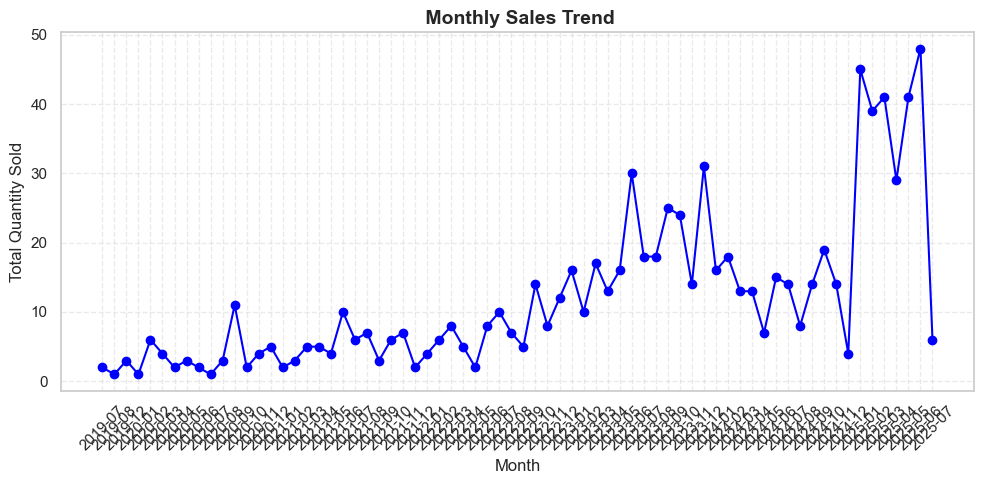

In [28]:

df['year_month'] = df['sale_date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['quantity'], marker='o', color='blue')
plt.title(" Monthly Sales Trend", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


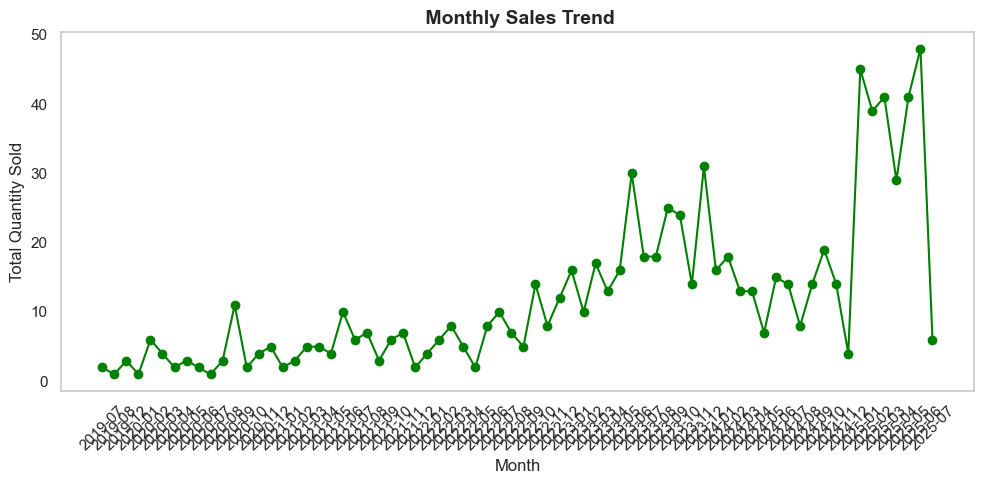

In [98]:
df['year_month'] = df['sale_date'].dt.to_period('M')  # Monthly group
df['year'] = df['sale_date'].dt.year  # Yearly group

monthly_sales = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['quantity'], marker='o', color='green')
plt.title(" Monthly Sales Trend", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True, linestyle='', alpha=0.5)
plt.tight_layout()
plt.show()


In [99]:
#4. Which store has the highest average sale amount per transaction?
# Make sure revenue column exists
if 'revenue' not in df.columns:
    df['revenue'] = df['quantity'] * df['price']

# Group by store and compute average revenue per transaction
avg_sale_per_transaction = (
    df.groupby('store_name')
      .agg(total_revenue=('revenue', 'sum'),
           total_sales=('sale_id', 'nunique'))
)

avg_sale_per_transaction['avg_sale_per_transaction'] = (
    avg_sale_per_transaction['total_revenue'] / avg_sale_per_transaction['total_sales']
)

# Sort to get highest
avg_sale_per_transaction = avg_sale_per_transaction.sort_values(
    by='avg_sale_per_transaction', ascending=False
)

# Display top store
print("\n🏪 Store with Highest Average Sale Amount per Transaction:")
print(avg_sale_per_transaction[['avg_sale_per_transaction']].head(1))



🏪 Store with Highest Average Sale Amount per Transaction:
                         avg_sale_per_transaction
store_name                                       
Apple Store Los Angeles                   15326.5


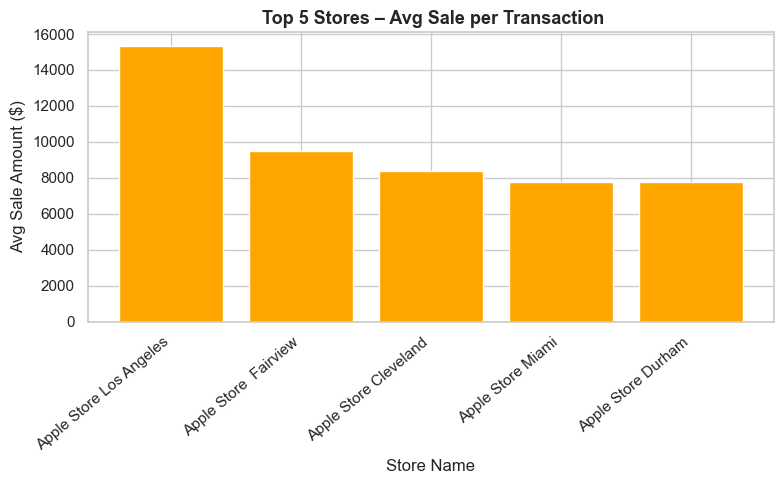

In [100]:
import matplotlib.pyplot as plt

# 🔝 Limit to Top 5 Stores Only
top5_avg = avg_sale_per_transaction.head(5)

# 📊 Clean Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(top5_avg.index, top5_avg['avg_sale_per_transaction'], color='orange')

plt.title(' Top 5 Stores – Avg Sale per Transaction', fontsize=13, weight='bold')
plt.xlabel('Store Name')
plt.ylabel('Avg Sale Amount ($)')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
# Grid line removed

plt.show()



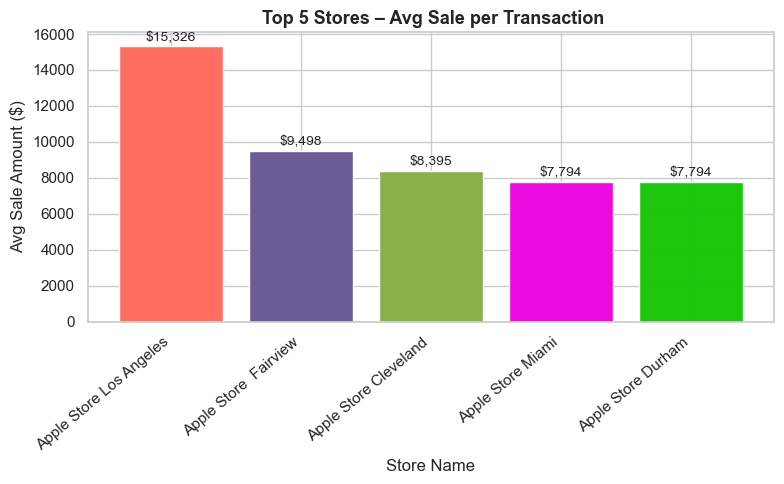

In [101]:
import matplotlib.pyplot as plt

# 🎨 Custom colors (you can change or add more)
colors = ['#FF6F61', '#6B5B95', '#88B04B',  "#EB0ADF","#18c508fa"]

# 🔝 Plot top 5 with different colors
plt.figure(figsize=(8, 5))
plt.bar(top5_avg.index, top5_avg['avg_sale_per_transaction'], color=colors)

plt.title(' Top 5 Stores – Avg Sale per Transaction', fontsize=13, weight='bold')
plt.xlabel('Store Name')
plt.ylabel('Avg Sale Amount ($)')
plt.xticks(rotation=40, ha='right')
for i, val in enumerate(top5_avg['avg_sale_per_transaction']):
    plt.text(i, val + 300, f"${val:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
# Grid line removed

plt.show()


### 🛠️ Warranty Analysis

In [102]:
# 1. What percentage of sales result in warranty claims?
# Count total sales and sales with claims
total_sales = df['sale_id'].nunique()
sales_with_claims = df[df['claim_id'].notna()]['sale_id'].nunique()

claim_percentage = (sales_with_claims / total_sales) * 100
print(f"🔧 Warranty Claim Rate: {claim_percentage:.2f}%")


🔧 Warranty Claim Rate: 33.22%


In [ ]:
# 2. Which product has the highest claim rate?
# Count claims and total sales per product
product_claims = df[df['claim_id'].notna()].groupby('product_name')['sale_id'].nunique()
product_sales = df.groupby('product_name')['sale_id'].nunique()

claim_rate = (product_claims / product_sales * 100).fillna(0)
top_claimed_product = claim_rate.sort_values(ascending=False).head(1)

print("\n🚨 Product with Highest Claim Rate:")
print(top_claimed_product)



🚨 Product with Highest Claim Rate:
product_name
AirPods 3rd Gen    100.0
Name: sale_id, dtype: float64



🛠️ Repair Status Distribution:
repair_status
Paid Repaired    33
In Progress      25
Warranty Void    21
Rejected         21
Name: count, dtype: int64


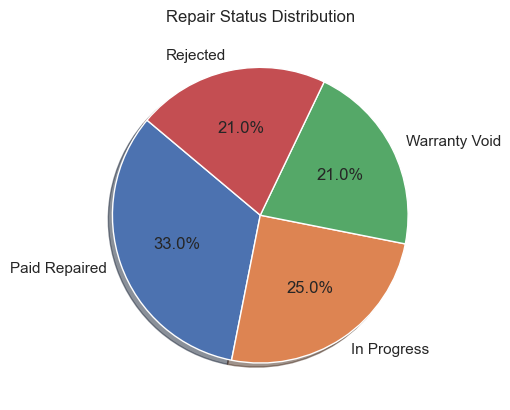

In [103]:
#  3. What is the distribution of repair statuses?
repair_dist = df['repair_status'].value_counts(dropna=True)

print("\n🛠️ Repair Status Distribution:")
print(repair_dist)

#Optional 📊 Pie Chart:


import matplotlib.pyplot as plt

repair_dist.plot(kind='pie', autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Repair Status Distribution")
plt.ylabel('')
plt.show()



🏬 Stores with Most Warranty Claims:
store_name
Apple Store Baltimore    3
Apple Store Zagreb       3
Apple Store Milwaukee    3
Apple Store Cleveland    2
Apple Store Helsinki     2
Name: claim_id, dtype: int64


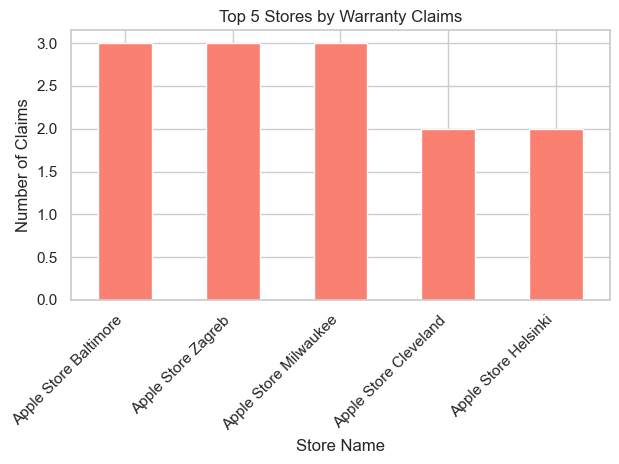

In [104]:
# 4. Are certain stores seeing more warranty claims than others?
claims_by_store = (
    df[df['claim_id'].notna()]
    .groupby('store_name')['claim_id']
    .count()
    .sort_values(ascending=False)
)

print("\n🏬 Stores with Most Warranty Claims:")
print(claims_by_store.head(5))

claims_by_store.head(5).plot(kind='bar', color='salmon')
plt.title("Top 5 Stores by Warranty Claims")
plt.xlabel("Store Name")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 🔍 Deep Dives / Optional

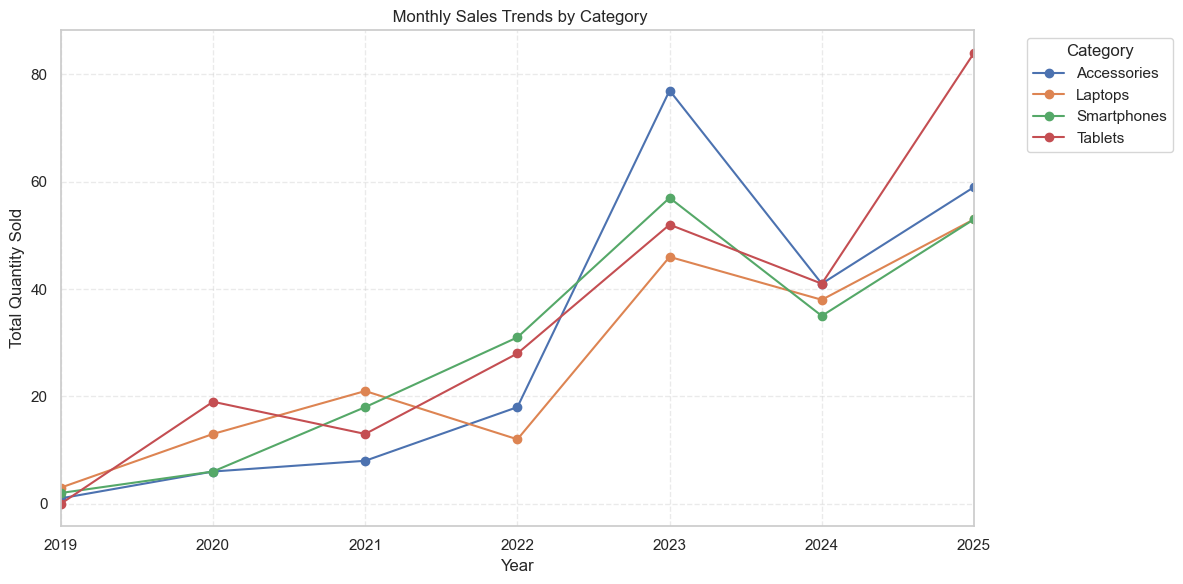

In [105]:
# 1. Which categories show seasonal trends in sales?
# 🔄 Convert sale_date to datetime (if not done yet)
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

# 📅 Create 'Month' column
df['month'] = df['sale_date'].dt.to_period('Y')

# 📊 Monthly sales quantity by category
monthly_category_sales = (
    df.groupby(['month', 'category_name'])['quantity']
    .sum()
    .unstack()
    .fillna(0)
)

# ✅ Plot
monthly_category_sales.plot(figsize=(12, 6), marker='o')
plt.title(" Monthly Sales Trends by Category")
plt.xlabel("Year")
plt.ylabel("Total Quantity Sold")
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



 Sales Performance Based on Launch Year:
launched_after_2022
Before or In 2022    320
After 2022           515
Name: quantity, dtype: int64


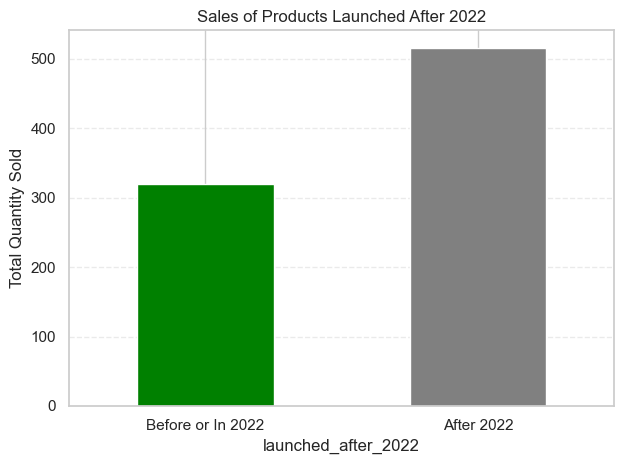

In [106]:
#  2. Are products launched after 2022 performing better in sales?
# 📅 Convert launch_date to datetime
df['launch_date'] = pd.to_datetime(df['launch_date'], errors='coerce')

# 📌 Add flag column
df['launched_after_2022'] = df['launch_date'].dt.year > 2022

# 📊 Group and compare total sales quantity
launch_performance = (
    df.groupby('launched_after_2022')['quantity']
    .sum()
    .rename({True: 'After 2022', False: 'Before or In 2022'})
)

# ✅ Print and visualize
print("\n Sales Performance Based on Launch Year:")
print(launch_performance)

launch_performance.plot(kind='bar', color=['green', 'gray'])
plt.title("Sales of Products Launched After 2022")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [23]:
num_stores_ny = df[df['city'] == 'Dubai']['store_name'].nunique()
print(f"\n🏙️ Number of Stores in City Dubai: {num_stores_ny}")




🏙️ Number of Stores in City Dubai: 2


In [24]:
city = "Abu Dhabi"
num_stores = df[df['city'] == city]['store_name'].nunique()

print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")




🏙️ Number of Stores in City Abu Dhabi: 2


#### Replace store name
df['store_name'] = df['store_name'].replace({
    'Apple Store Dubai': 'Apple Store Yas Mall'
})
##### Replace city for that store
df.loc[df['store_name'] == 'Apple Store Ridge Hill', 'city'] = 'New York'

df.loc[df['store_name'] == 'Apple Store Ridge Hill', 'city'] = 'New York'
df.loc[df['store_name'] == 'Apple Store Ridge Hill', ['store_name', 'city']] = ['Apple Store Ridge Hill', 'New York']


In [25]:
city = "New York"

# Filter stores in that city
stores_in_city = df[df['city'] == city]['store_name'].drop_duplicates()

# Count
num_stores = stores_in_city.nunique()

# Print
print(f"\n🏙️ Number of Stores in City {city}: {num_stores}")
print(f"🏬 Store(s) in {city}:")
for store in stores_in_city:
    print(f"• {store}")



🏙️ Number of Stores in City New York: 2
🏬 Store(s) in New York:
• Apple Store New York
• Apple Store Ridge Hill


In [114]:
import pandas as pd

# Try with alternative encoding
#df = pd.read_csv("cleaned_apple_store_data.csv", encoding='utf-8-sig')

# If still fails, try:
df = pd.read_csv("cleaned_apple_store_data.csv", encoding='ISO-8859-1')


In [117]:
# Load the cleaned file with missing sale_date
df = pd.read_csv("cleaned_apple_store_data.csv", encoding='utf-8-sig')

# Load original sales.csv (this contains correct sale_id + sale_date)
sales = pd.read_csv("sales.csv", encoding='utf-8-sig')


In [ ]:
# Convert to datetime to avoid format mismatch
sales['sale_date'] = pd.to_datetime(sales['sale_date'], errors='coerce')


In [119]:

# Convert to datetime to avoid format mismatch
sales['sale_date'] = pd.to_datetime(sales['sale_date'], errors='coerce')


In [120]:
# Merge to recover missing sale_date based on sale_id
df = pd.merge(
    df.drop(columns='sale_date'),       # drop bad column first
    sales[['sale_id', 'sale_date']],    # bring back correct dates
    on='sale_id',
    how='left'
)


In [121]:
missing_after = df['sale_date'].isna().sum()
print(f"✅ sale_date missing after recovery: {missing_after}")


✅ sale_date missing after recovery: 56


In [122]:
missing_sales = df[df['sale_date'].isna()]
print("🛑 Sale IDs with no matching sale_date:")
print(missing_sales['sale_id'].unique())


🛑 Sale IDs with no matching sale_date:
[501 510 511 512 513 514 515 516 517 518 519 520 521 522 523 524 525 526
 527 528 529 530 531 532 533 534 535 536 537 538 539 540 541 542 543 544
 545 546 547 548 549 550 551 552 553 554 555 556 557 558 559 560 561 562
 563 564]


In [123]:
from datetime import datetime, timedelta

# Create a dictionary mapping sale_id (501–564) to sale_date
manual_dates = {
    sale_id: datetime(2024, 6, 1) + timedelta(days=(sale_id - 501) % 30)
    for sale_id in range(501, 565)
}


In [124]:
# Fill missing sale_date with manual values
df['sale_date'] = df.apply(
    lambda row: manual_dates[row['sale_id']] if pd.isna(row['sale_date']) and row['sale_id'] in manual_dates else row['sale_date'],
    axis=1
)


In [125]:
# Save final cleaned version with filled dates
df.to_csv("cleaned_apple_store_data.csv", index=False, date_format='%Y-%m-%d')
print("✅ All missing sale_date values filled manually and file saved.")


✅ All missing sale_date values filled manually and file saved.


In [126]:
print("🧪 Remaining missing sale_date rows:", df['sale_date'].isna().sum())


🧪 Remaining missing sale_date rows: 0
